# Compression Neuronale vs JPEG

**Objectif** : Tester `bmshj2018_factorized` et `mbt2018_mean` (CompressAI) sur tous les niveaux de qualité (q=1 à 8),
comparer avec JPEG.

- Image test : région 5000×5000 extraite d'une lame SVS
- Modèles : poids pré-entraînés CompressAI 

In [12]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from io import BytesIO
import time

from compressai.zoo import bmshj2018_factorized, mbt2018_mean

In [2]:
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DOCS_DIR = Path('../docs/static/images/learned_compression')
DOCS_DIR.mkdir(parents=True, exist_ok=True)

IMG_PATH = DATA_DIR / 'region_5000.png'
print(f'Image test: {IMG_PATH}')

Device: mps
Image test: data/region_5000.png


In [3]:
def load_image(path):
    img = Image.open(path).convert('RGB')
    return np.array(img), img.size

img_np, (W, H) = load_image(IMG_PATH)
print(f'Taille: {W}×{H}, Shape: {img_np.shape}')
print(f'PNG original: {Path(IMG_PATH).stat().st_size / 1024:.0f} KB')

Taille: 5000×5000, Shape: (5000, 5000, 3)
PNG original: 36484 KB


In [4]:
def calculate_psnr(original, reconstructed):
    mse = np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    return 10 * np.log10(255.0 ** 2 / mse)

def calculate_bpp(likelihoods, num_pixels):
    total_bits = 0
    for key in likelihoods:
        bits = -torch.log2(likelihoods[key]).sum()
        total_bits += bits.item()
    return total_bits / num_pixels

def pad_to_multiple(tensor, multiple=64):
    _, _, h, w = tensor.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    if pad_h > 0 or pad_w > 0:
        tensor = F.pad(tensor, (0, pad_w, 0, pad_h), mode='reflect')
    return tensor, pad_h, pad_w

def crop_to_original(tensor, pad_h, pad_w):
    if pad_h > 0 or pad_w > 0:
        h = tensor.shape[2] - pad_h
        w = tensor.shape[3] - pad_w
        return tensor[:, :, :h, :w]
    return tensor

## 1. Benchmark JPEG (référence)

In [5]:
jpeg_results = []

for quality in [10, 30, 50, 70, 90]:
    buf = BytesIO()
    img = Image.fromarray(img_np)
    img.save(buf, format='JPEG', quality=quality)
    size_bytes = buf.tell()
    buf.seek(0)
    jpeg_np = np.array(Image.open(buf).convert('RGB'))
    
    bpp = (size_bytes * 8) / (img_np.shape[0] * img_np.shape[1])
    psnr = calculate_psnr(img_np, jpeg_np)
    size_kb = size_bytes / 1024
    
    jpeg_results.append({
        'Méthode': 'JPEG',
        'Qualité': f'Q={quality}',
        'BPP': round(bpp, 4),
        'PSNR (dB)': round(psnr, 1),
        'Taille (KB)': round(size_kb, 0)
    })
    print(f'JPEG Q={quality:>2}  |  BPP={bpp:.4f}  |  PSNR={psnr:.1f} dB  |  {size_kb:.0f} KB')

JPEG Q=10  |  BPP=0.3299  |  PSNR=28.8 dB  |  1007 KB
JPEG Q=30  |  BPP=0.6426  |  PSNR=33.3 dB  |  1961 KB
JPEG Q=50  |  BPP=0.8616  |  PSNR=35.2 dB  |  2629 KB
JPEG Q=70  |  BPP=1.1428  |  PSNR=36.9 dB  |  3487 KB
JPEG Q=90  |  BPP=2.0687  |  PSNR=40.2 dB  |  6313 KB


## 2. Benchmark bmshj2018_factorized (q=1 à 8)

In [6]:
print('=== bmshj2018_factorized ===')

bmshj_results = []
x = torch.from_numpy(img_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
x_padded, pad_h, pad_w = pad_to_multiple(x, multiple=64)
num_pixels = img_np.shape[0] * img_np.shape[1]

for quality in range(1, 9):
    t0 = time.time()
    print(f'Loading bmshj2018_factorized q={quality}...', end=' ')
    model = bmshj2018_factorized(quality=quality, pretrained=True).eval().to(DEVICE)
    
    with torch.no_grad():
        x_gpu = x_padded.to(DEVICE)
        out = model(x_gpu)
        bpp = calculate_bpp(out['likelihoods'], num_pixels)
        x_hat = crop_to_original(out['x_hat'], pad_h, pad_w)
        x_hat_np = (x_hat.squeeze().permute(1, 2, 0).cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
        psnr = calculate_psnr(img_np, x_hat_np)
    
    size_kb = bpp * num_pixels / 8 / 1024
    elapsed = time.time() - t0
    
    bmshj_results.append({
        'Méthode': 'bmshj2018_factorized',
        'Qualité': f'q={quality}',
        'BPP': round(bpp, 4),
        'PSNR (dB)': round(psnr, 2),
        'Taille (KB)': round(size_kb, 0)
    })
    
    # Sauvegarder la reconstruction
    recon_path = OUTPUT_DIR / f'bmshj2018_q{quality}.png'
    Image.fromarray(x_hat_np).save(recon_path)
    
    print(f'BPP={bpp:.4f}  PSNR={psnr:.2f} dB  ({size_kb:.0f} KB)  [{elapsed:.1f}s]')

=== bmshj2018_factorized ===
Loading bmshj2018_factorized q=1... BPP=0.1441  PSNR=28.66 dB  (440 KB)  [4.4s]
Loading bmshj2018_factorized q=2... BPP=0.2119  PSNR=30.27 dB  (647 KB)  [5.3s]
Loading bmshj2018_factorized q=3... BPP=0.3027  PSNR=31.86 dB  (924 KB)  [5.0s]
Loading bmshj2018_factorized q=4... BPP=0.4298  PSNR=33.68 dB  (1312 KB)  [3.1s]
Loading bmshj2018_factorized q=5... BPP=0.5908  PSNR=35.48 dB  (1803 KB)  [3.0s]
Loading bmshj2018_factorized q=6... BPP=0.7908  PSNR=37.18 dB  (2413 KB)  [19.8s]
Loading bmshj2018_factorized q=7... BPP=1.0649  PSNR=39.03 dB  (3250 KB)  [48.0s]
Loading bmshj2018_factorized q=8... BPP=1.4243  PSNR=40.83 dB  (4347 KB)  [63.1s]


## 3. Benchmark mbt2018_mean (q=1 à 8)

In [7]:
print('=== mbt2018_mean ===')

mbt_results = []

for quality in range(1, 9):
    t0 = time.time()
    print(f'Loading mbt2018_mean q={quality}...', end=' ')
    model = mbt2018_mean(quality=quality, pretrained=True).eval().to(DEVICE)
    
    with torch.no_grad():
        x_gpu = x_padded.to(DEVICE)
        out = model(x_gpu)
        bpp = calculate_bpp(out['likelihoods'], num_pixels)
        x_hat = crop_to_original(out['x_hat'], pad_h, pad_w)
        x_hat_np = (x_hat.squeeze().permute(1, 2, 0).cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
        psnr = calculate_psnr(img_np, x_hat_np)
    
    size_kb = bpp * num_pixels / 8 / 1024
    elapsed = time.time() - t0
    
    mbt_results.append({
        'Méthode': 'mbt2018_mean',
        'Qualité': f'q={quality}',
        'BPP': round(bpp, 4),
        'PSNR (dB)': round(psnr, 2),
        'Taille (KB)': round(size_kb, 0)
    })
    
    # Sauvegarder la reconstruction
    recon_path = OUTPUT_DIR / f'mbt2018_q{quality}.png'
    Image.fromarray(x_hat_np).save(recon_path)
    
    print(f'BPP={bpp:.4f}  PSNR={psnr:.2f} dB  ({size_kb:.0f} KB)  [{elapsed:.1f}s]')

print('mbt2018_mean terminé.')

=== mbt2018_mean ===
Loading mbt2018_mean q=1... BPP=0.1234  PSNR=28.89 dB  (377 KB)  [79.5s]
Loading mbt2018_mean q=2... Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-2-e54a039d.pth.tar" to /Users/nath/.cache/torch/hub/checkpoints/mbt2018-mean-2-e54a039d.pth.tar


100%|██████████| 27.6M/27.6M [00:05<00:00, 5.16MB/s]


BPP=0.1832  PSNR=30.56 dB  (559 KB)  [92.0s]
Loading mbt2018_mean q=3... BPP=0.2646  PSNR=32.26 dB  (808 KB)  [76.5s]
Loading mbt2018_mean q=4... Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-4-6dba02a3.pth.tar" to /Users/nath/.cache/torch/hub/checkpoints/mbt2018-mean-4-6dba02a3.pth.tar


100%|██████████| 27.6M/27.6M [00:06<00:00, 4.27MB/s]


BPP=0.3708  PSNR=34.01 dB  (1132 KB)  [82.1s]
Loading mbt2018_mean q=5... BPP=0.5107  PSNR=35.76 dB  (1559 KB)  [63.0s]
Loading mbt2018_mean q=6... Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-6-a19628ab.pth.tar" to /Users/nath/.cache/torch/hub/checkpoints/mbt2018-mean-6-a19628ab.pth.tar


100%|██████████| 67.9M/67.9M [00:23<00:00, 3.07MB/s]


BPP=0.6850  PSNR=37.68 dB  (2091 KB)  [111.4s]
Loading mbt2018_mean q=7... BPP=0.9201  PSNR=39.54 dB  (2808 KB)  [128.1s]
Loading mbt2018_mean q=8... Downloading: "https://compressai.s3.amazonaws.com/models/v1/mbt2018-mean-8-8089ae3e.pth.tar" to /Users/nath/.cache/torch/hub/checkpoints/mbt2018-mean-8-8089ae3e.pth.tar


100%|██████████| 67.9M/67.9M [00:17<00:00, 4.15MB/s]


BPP=1.2390  PSNR=41.39 dB  (3781 KB)  [115.7s]
mbt2018_mean terminé.


## 4. Résultats complets

In [8]:
df = pd.DataFrame(jpeg_results + bmshj_results + mbt_results)
print(f'\n=== Résultats ({len(df)} configurations) ===')

df_jpeg = df[df['Méthode'] == 'JPEG']
df_bmshj = df[df['Méthode'] == 'bmshj2018_factorized']
df_mbt = df[df['Méthode'] == 'mbt2018_mean']

print('\n--- JPEG ---')
display(df_jpeg[['Qualité', 'BPP', 'PSNR (dB)', 'Taille (KB)']].to_string(index=False))

print('\n--- bmshj2018_factorized ---')
display(df_bmshj[['Qualité', 'BPP', 'PSNR (dB)', 'Taille (KB)']].to_string(index=False))

print('\n--- mbt2018_mean ---')
display(df_mbt[['Qualité', 'BPP', 'PSNR (dB)', 'Taille (KB)']].to_string(index=False))

df.to_csv(OUTPUT_DIR / 'results_complete.csv', index=False)
print(f'\nRésultats sauvegardés: {OUTPUT_DIR / "results_complete.csv"}')


=== Résultats (21 configurations) ===

--- JPEG ---


'Qualité    BPP  PSNR (dB)  Taille (KB)\n   Q=10 0.3299       28.8       1007.0\n   Q=30 0.6426       33.3       1961.0\n   Q=50 0.8616       35.2       2629.0\n   Q=70 1.1428       36.9       3487.0\n   Q=90 2.0687       40.2       6313.0'


--- bmshj2018_factorized ---


'Qualité    BPP  PSNR (dB)  Taille (KB)\n    q=1 0.1441      28.66        440.0\n    q=2 0.2119      30.27        647.0\n    q=3 0.3027      31.86        924.0\n    q=4 0.4298      33.68       1312.0\n    q=5 0.5908      35.48       1803.0\n    q=6 0.7908      37.18       2413.0\n    q=7 1.0649      39.03       3250.0\n    q=8 1.4243      40.83       4347.0'


--- mbt2018_mean ---


'Qualité    BPP  PSNR (dB)  Taille (KB)\n    q=1 0.1234      28.89        377.0\n    q=2 0.1832      30.56        559.0\n    q=3 0.2646      32.26        808.0\n    q=4 0.3708      34.01       1132.0\n    q=5 0.5107      35.76       1559.0\n    q=6 0.6850      37.68       2091.0\n    q=7 0.9201      39.54       2808.0\n    q=8 1.2390      41.39       3781.0'


Résultats sauvegardés: outputs/results_complete.csv


## 5. Courbe

Courbe sauvegardée: outputs/rate_distortion_curve.png
Copiée dans docs: ../docs/static/images/learned_compression/rate_distortion_curve.png


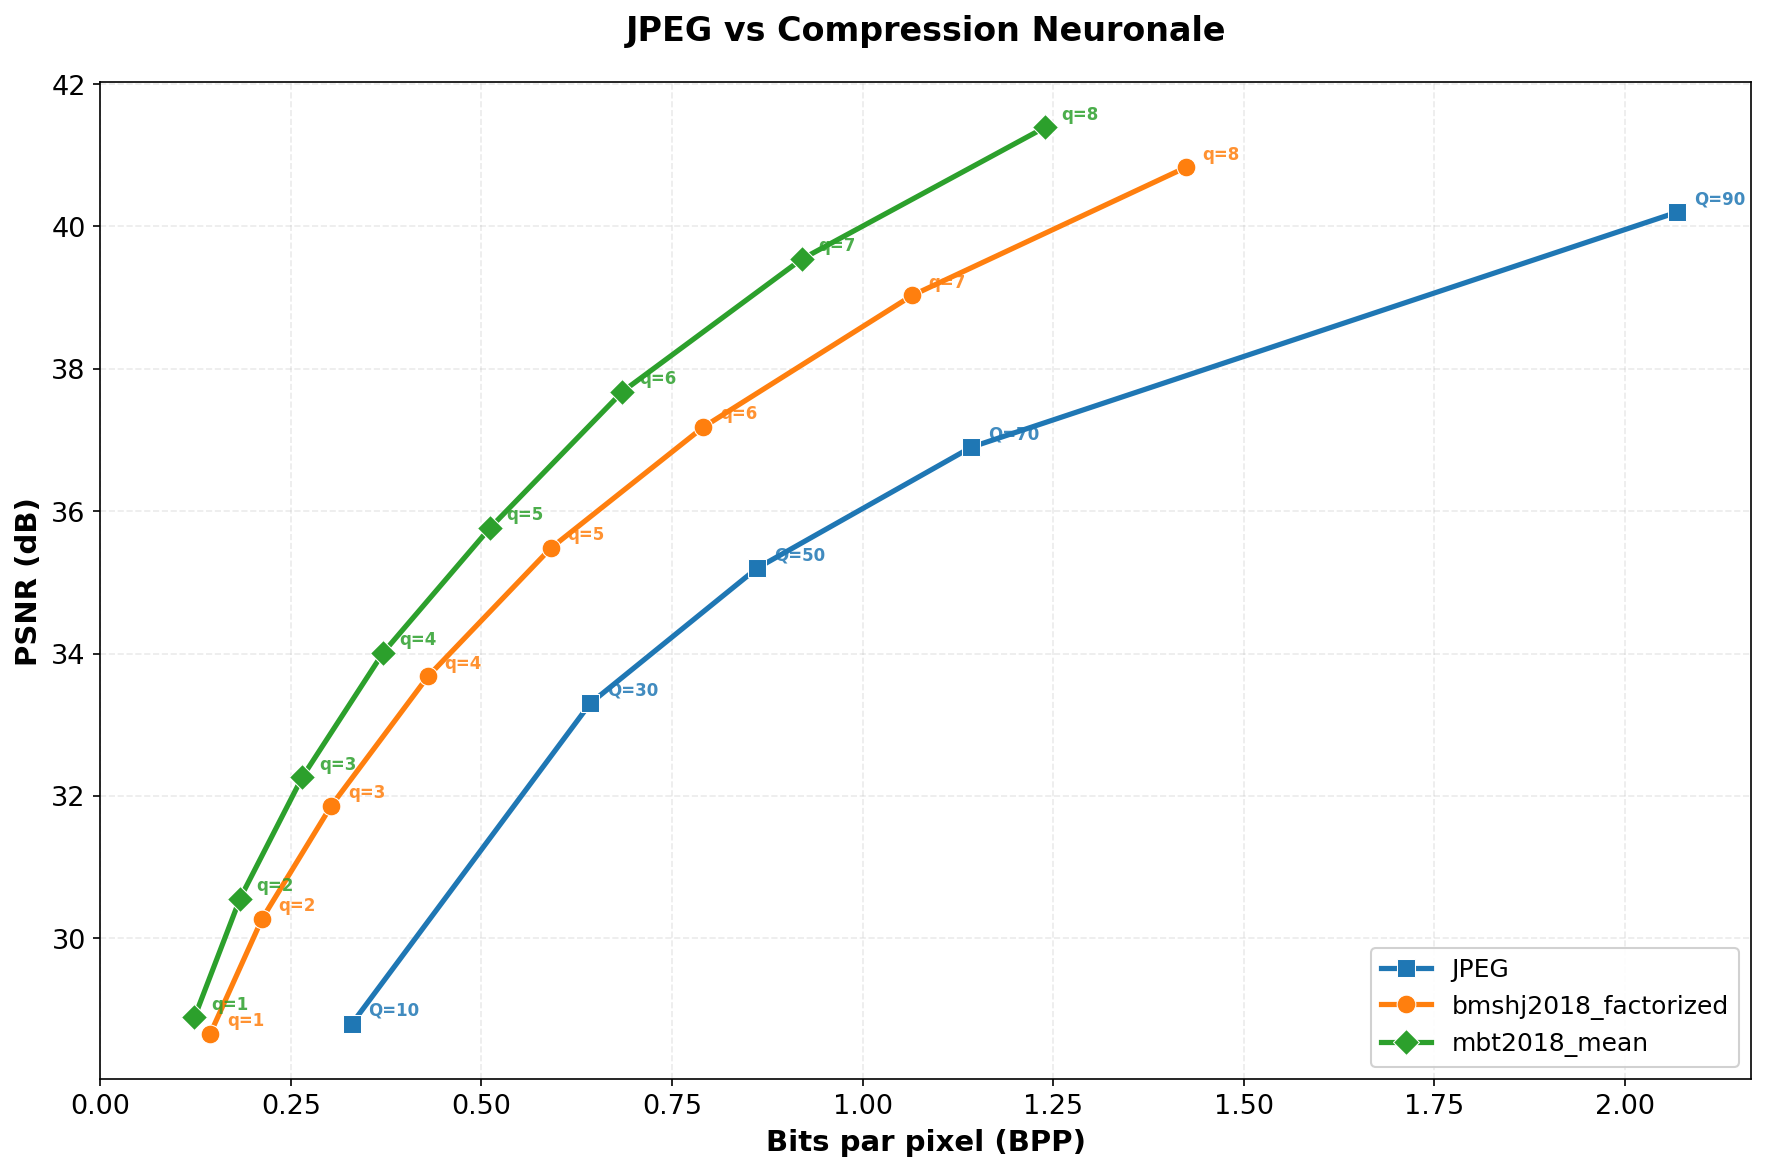

In [13]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'figure.dpi': 150
})

fig, ax = plt.subplots(figsize=(12, 8))

colors = {
    'JPEG': '#1f77b4',
    'bmshj2018_factorized': '#ff7f0e',
    'mbt2018_mean': '#2ca02c'
}

markers = {
    'JPEG': 's',
    'bmshj2018_factorized': 'o',
    'mbt2018_mean': 'D'
}

for method in ['JPEG', 'bmshj2018_factorized', 'mbt2018_mean']:
    subset = df[df['Méthode'] == method].sort_values('BPP')
    ax.plot(subset['BPP'], subset['PSNR (dB)'],
            marker=markers[method], linewidth=2.5, markersize=9,
            label=method, color=colors[method], markeredgewidth=0.5,
            markeredgecolor='white')
    
    # Annoter chaque point avec sa qualité
    for _, row in subset.iterrows():
        ax.annotate(row['Qualité'],
                    (row['BPP'], row['PSNR (dB)']),
                    textcoords='offset points',
                    xytext=(8, 4),
                    fontsize=8, fontweight='bold',
                    color=colors[method], alpha=0.85)

ax.set_xlabel('Bits par pixel (BPP)', fontweight='bold')
ax.set_ylabel('PSNR (dB)', fontweight='bold')
ax.set_title('JPEG vs Compression Neuronale',
             fontweight='bold', pad=20)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='#ccc')
ax.grid(True, alpha=0.25, linestyle='--')
ax.set_xlim(left=0)

plt.tight_layout()

curve_path = OUTPUT_DIR / 'rate_distortion_curve.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Courbe sauvegardée: {curve_path}')

# Copier dans les docs
import shutil
docs_path = DOCS_DIR / 'rate_distortion_curve.png'
shutil.copy(curve_path, docs_path)
print(f'Copiée dans docs: {docs_path}')

plt.show()

## 6. Comparaisons visuelles clés

On génère des images de comparaison pour les niveaux de qualité les plus pertinents (q=3 et q=5) pour les docs.

In [ ]:
def save_comparison(recon_np, name, target_dir):
    """Sauvegarde la reconstruction en PNG pour les docs."""
    path = target_dir / f'{name}.png'
    Image.fromarray(recon_np).save(path)
    size_kb = path.stat().st_size / 1024
    print(f'  {path.name} ({size_kb:.0f} KB)')

print('=== Génération des images de comparaison pour les docs ===')

for q in [3, 5]:
    for model_name in ['bmshj2018', 'mbt2018']:
        src = OUTPUT_DIR / f'{model_name}_q{q}.png'
        dst = DOCS_DIR / f'{model_name}_q{q}.png'
        if src.exists():
            shutil.copy(src, dst)
            print(f'  {src.name} -> docs/')

# Sauvegarder aussi l'original en JPEG pour les docs
original_jpg = DOCS_DIR / 'region_5000_original.jpg'
Image.fromarray(img_np).save(original_jpg, 'JPEG', quality=92)
print(f'  Original -> {original_jpg.name} ({original_jpg.stat().st_size/1024:.0f} KB)')

# JPEG Q=30 pour comparaison
jpeg30_path = DOCS_DIR / 'region_5000_JPEG_Q30.jpg'
buf = BytesIO()
Image.fromarray(img_np).save(buf, format='JPEG', quality=30)
buf.seek(0)
Image.open(buf).save(jpeg30_path)
print(f'  JPEG Q=30 -> {jpeg30_path.name} ({jpeg30_path.stat().st_size/1024:.0f} KB)')

print('\nToutes les images sont dans docs/static/images/learned_compression/')

=== Génération des images de comparaison pour les docs ===
  bmshj2018_q3.png -> docs/
  mbt2018_q3.png -> docs/
  bmshj2018_q5.png -> docs/
  mbt2018_q5.png -> docs/
  Original -> region_5000_original.jpg (6945 KB)
  JPEG Q=30 -> region_5000_JPEG_Q30.jpg (2840 KB)

Toutes les images sont dans docs/static/images/learned_compression/


## 7. Résumé comparatif

In [14]:
print('=== MEILLEUR RAPPORT QUALITÉ/TAILLE ===')
print()

# Trouver le meilleur PSNR pour un BPP donné
for target_psnr in [32, 35, 38]:
    print(f'--- Proche de {target_psnr} dB ---')
    candidates = df[df['PSNR (dB)'].between(target_psnr - 1, target_psnr + 1)].sort_values('BPP')
    if not candidates.empty:
        best = candidates.iloc[0]
        print(f'  Meilleur: {best["Méthode"]} {best["Qualité"]}  |  BPP={best["BPP"]:.4f}  PSNR={best["PSNR (dB)"]:.1f} dB  |  {best["Taille (KB)"]:.0f} KB')
    print()

print('=== COMPARAISON mbt2018_mean vs bmshj2018_factorized ===')
for q in [1, 3, 5, 8]:
    b = df_bmshj[df_bmshj['Qualité'] == f'q={q}']
    m = df_mbt[df_mbt['Qualité'] == f'q={q}']
    if len(b) and len(m):
        b = b.iloc[0]
        m = m.iloc[0]
        print(f'q={q}: bmshj BPP={b["BPP"]:.4f} PSNR={b["PSNR (dB)"]:.1f}  |  mbt2018 BPP={m["BPP"]:.4f} PSNR={m["PSNR (dB)"]:.1f}')

=== MEILLEUR RAPPORT QUALITÉ/TAILLE ===

--- Proche de 32 dB ---
  Meilleur: mbt2018_mean q=3  |  BPP=0.2646  PSNR=32.3 dB  |  808 KB

--- Proche de 35 dB ---
  Meilleur: mbt2018_mean q=4  |  BPP=0.3708  PSNR=34.0 dB  |  1132 KB

--- Proche de 38 dB ---
  Meilleur: mbt2018_mean q=6  |  BPP=0.6850  PSNR=37.7 dB  |  2091 KB

=== COMPARAISON mbt2018_mean vs bmshj2018_factorized ===
q=1: bmshj BPP=0.1441 PSNR=28.7  |  mbt2018 BPP=0.1234 PSNR=28.9
q=3: bmshj BPP=0.3027 PSNR=31.9  |  mbt2018 BPP=0.2646 PSNR=32.3
q=5: bmshj BPP=0.5908 PSNR=35.5  |  mbt2018 BPP=0.5107 PSNR=35.8
q=8: bmshj BPP=1.4243 PSNR=40.8  |  mbt2018 BPP=1.2390 PSNR=41.4
